The purpose of the case study is to classify a given silhouette as one of four different types of vehicle, using a set of features extracted from the silhouette. The vehicle may be viewed from one of many different angles.
Four &quot;Corgie&quot; model vehicles were used for the experiment: a double decker bus, Cheverolet
van, Saab 9000 and an Opel Manta 400 cars. This particular combination of vehicles was chosen with the expectation that the bus, van and either one of the cars would be readily distinguishable, but it would be more difficult to distinguish between the cars.
The purpose is to classify a given silhouette as one of three types of vehicle, using a set of features extracted from the silhouette. The vehicle may be viewed from one of many different angles.
 
Link to the case file: vehicle.csvView in a new window

 
The points distribution for this case is as follows:
1. Use a new Python notebook and read the data set. Data pre-processing - Understand the data and treat missing values (Use box plot), outliers (5 points)
2. Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)
3. Use PCA from scikit learn and elbow plot to find out reduced number of dimension (which covers more than 95% of the variance) - 10 points
4. Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)



## Question 1. Use a new Python notebook and read the data set. Data pre-processing - Understand the data and treat missing values (Use box plot), outliers (5 points)

In [1]:
#Import all the packages required for the program to run
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn import metrics

import matplotlib.pyplot as plt
from matplotlib import pyplot
import seaborn as sn

from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import multiprocessing 
from sklearn.model_selection import GridSearchCV
from sklearn import svm
import time

##### Load data from CSV file

In [2]:
#load the dataset
vehicle_df = pd.read_csv("vehicle.csv", na_values= '?')

#view top 10 rows
vehicle_df.head().transpose()

,0,1,2,3,4
compactness,95,91,104,93,85
circularity,48,41,50,41,44
distance_circularity,83,84,106,82,70
radius_ratio,178,141,209,159,205
pr.axis_aspect_ratio,72,57,66,63,103
max.length_aspect_ratio,10,9,10,9,52
scatter_ratio,162,149,207,144,149
elongatedness,42,45,32,46,45
pr.axis_rectangularity,20,19,23,19,19
max.length_rectangularity,159,143,158,143,144


In [3]:
vehicle_df.shape

(846, 19)

In [4]:
#Count the number of null values in each columns
vehicle_df.isnull().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

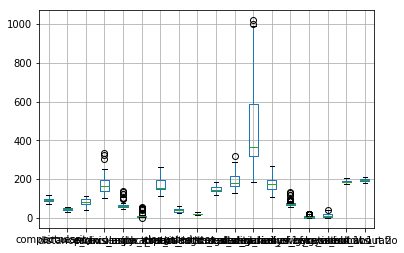

In [5]:
vehicle_df.boxplot()

In [6]:
# Remove the ouliers from dataset
Q1 = vehicle_df.quantile(0.25)
Q3 = vehicle_df.quantile(0.75)
IQR = Q3 - Q1

vehicle_new_df = vehicle_df[~((vehicle_df < (Q1 - 1.5 * IQR)) |(vehicle_df > (Q3 + 1.5 * IQR))).any(axis=1)]
vehicle_new_df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
5,107,NaN,106.0,172.0,50.0,6,255.0,26.0,28.0,169,280.0,957.0,264.0,85.0,5.0,9.0,181.0,183,bus


In [7]:
vehicle_new_df.shape

(813, 19)

In [8]:
#Count again the number of null values in each columns
vehicle_new_df.isnull().sum()

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

In [9]:
veh_new_df = vehicle_new_df.dropna()
veh_new_df.shape

(780, 19)

In [10]:
veh_new_df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
6,97,43.0,73.0,173.0,65.0,6,153.0,42.0,19.0,143,176.0,361.0,172.0,66.0,13.0,1.0,200.0,204,bus


In [11]:
le = preprocessing.LabelEncoder()
le.fit(veh_new_df['class'])
veh_new_df['class'] = le.transform(veh_new_df['class'])
le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(le_name_mapping)

{'bus': 0, 'car': 1, 'van': 2}


/home/siju/.local/lib/python3.6/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [12]:
#print the info of each attributes, make sure the datatype is numerical type
veh_new_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 845
Data columns (total 19 columns):
compactness                    780 non-null int64
circularity                    780 non-null float64
distance_circularity           780 non-null float64
radius_ratio                   780 non-null float64
pr.axis_aspect_ratio           780 non-null float64
max.length_aspect_ratio        780 non-null int64
scatter_ratio                  780 non-null float64
elongatedness                  780 non-null float64
pr.axis_rectangularity         780 non-null float64
max.length_rectangularity      780 non-null int64
scaled_variance                780 non-null float64
scaled_variance.1              780 non-null float64
scaled_radius_of_gyration      780 non-null float64
scaled_radius_of_gyration.1    780 non-null float64
skewness_about                 780 non-null float64
skewness_about.1               780 non-null float64
skewness_about.2               780 non-null float64
hollows_ratio    

##  Question 2. Understanding the attributes - Find relationship between different attributes (Independent variables) and choose carefully which all attributes have to be a part of the analysis and why (5 points)

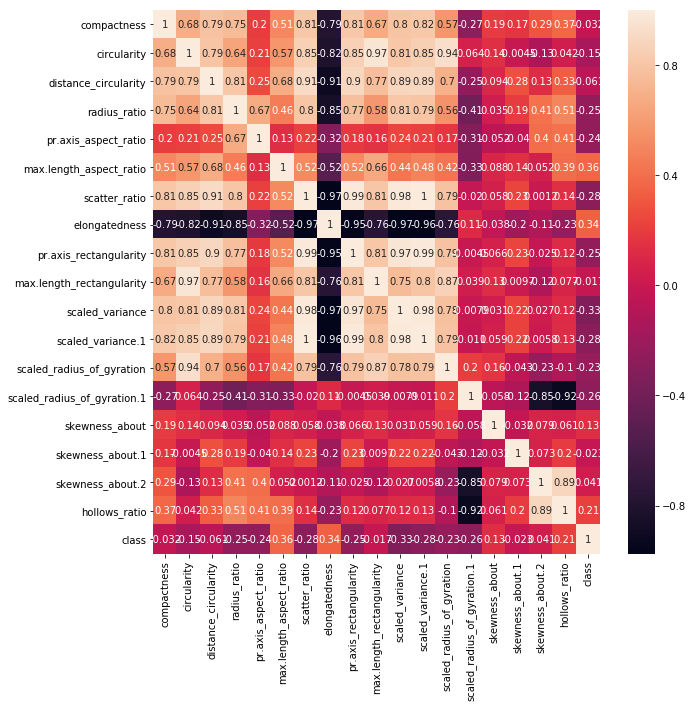

In [13]:
# The independent variables correlation can be observed using pyplot 
corrmat = veh_new_df.corr()
pyplot.subplots(figsize = (10,10))
sn.heatmap(corrmat, annot=True)

In [14]:
veh_new_df.corr()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
compactness,1.000000,0.684463,0.786735,0.745973,0.202780,0.512992,0.812183,-0.787736,0.812259,0.672707,0.795670,0.819090,0.573073,-0.265972,0.194010,0.173521,0.292936,0.372124,-0.031538
circularity,0.684463,1.000000,0.792272,0.644664,0.208968,0.570953,0.854425,-0.819365,0.853588,0.965451,0.814018,0.848324,0.935478,0.063547,0.137352,-0.004494,-0.127245,0.042117,-0.152298
distance_circularity,0.786735,0.792272,1.000000,0.814214,0.254840,0.680406,0.909850,-0.910071,0.899440,0.767314,0.890100,0.894518,0.702305,-0.254880,0.094019,0.276400,0.127347,0.332408,-0.061496
radius_ratio,0.745973,0.644664,0.814214,1.000000,0.671836,0.464090,0.801104,-0.852409,0.774223,0.578226,0.807730,0.792974,0.559548,-0.406807,0.035476,0.192709,0.412440,0.505777,-0.245705
pr.axis_aspect_ratio,0.202780,0.208968,0.254840,0.671836,1.000000,0.132552,0.217239,-0.316967,0.183402,0.155055,0.236408,0.206699,0.173064,-0.311479,-0.052074,-0.040333,0.397117,0.410590,-0.243001
max.length_aspect_ratio,0.512992,0.570953,0.680406,0.464090,0.132552,1.000000,0.517839,-0.517231,0.520456,0.661072,0.435552,0.483544,0.423314,-0.332615,0.088197,0.140914,0.051624,0.393788,0.363965
scatter_ratio,0.812183,0.854425,0.909850,0.801104,0.217239,0.517839,1.000000,-0.974338,0.991830,0.806004,0.980721,0.996610,0.790257,-0.019933,0.057670,0.230110,0.001226,0.137163,-0.281725
elongatedness,-0.787736,-0.819365,-0.910071,-0.852409,-0.316967,-0.517231,-0.974338,1.000000,-0.951465,-0.764761,-0.968186,-0.959171,-0.757245,0.107801,-0.038191,-0.201036,-0.107449,-0.228446,0.341398
pr.axis_rectangularity,0.812259,0.853588,0.899440,0.774223,0.183402,0.520456,0.991830,-0.951465,1.000000,0.811475,0.967083,0.991942,0.787922,-0.004491,0.066112,0.234218,-0.025401,0.117211,-0.247541
max.length_rectangularity,0.672707,0.965451,0.767314,0.578226,0.155055,0.661072,0.806004,-0.764761,0.811475,1.000000,0.749804,0.795824,0.865741,0.039211,0.128150,0.009657,-0.122437,0.077456,-0.017478


#### Attribute 'elongatedness' is highly correlated with most of the other attributes, that an be removed
#### 'skewness_about.2' and 'hollows_ratio' are highly correlated
#### 'scaled_radius_of_gyration.1' is highly correlated with 'skewness_about.2' and 'hollows_ratio'

### But since we are applying PCA, correlated will get solved by the dimentionality reduction.

In [15]:
veh_new_df.drop(columns='elongatedness', inplace=True)

/home/siju/.local/lib/python3.6/site-packages/pandas/core/frame.py:4097: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [16]:
veh_new_df.shape

(780, 18)

## Question 3. Use PCA from scikit learn and elbow plot to find out reduced number of dimension (which covers more than 95% of the variance) - 10 points


In [17]:
X = veh_new_df.drop(columns='class')
y = veh_new_df['class']

In [18]:
X_scale = StandardScaler().fit_transform(X)
X = X_scale

/home/siju/.local/lib/python3.6/site-packages/sklearn/preprocessing/data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
/home/siju/.local/lib/python3.6/site-packages/sklearn/base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


In [19]:
X_centered = X - X.mean(axis=0)

pca = PCA(n_components=17)
pca.fit(X_centered)

X_pca = pca.transform(X_centered)
X_pca.shape

(780, 17)

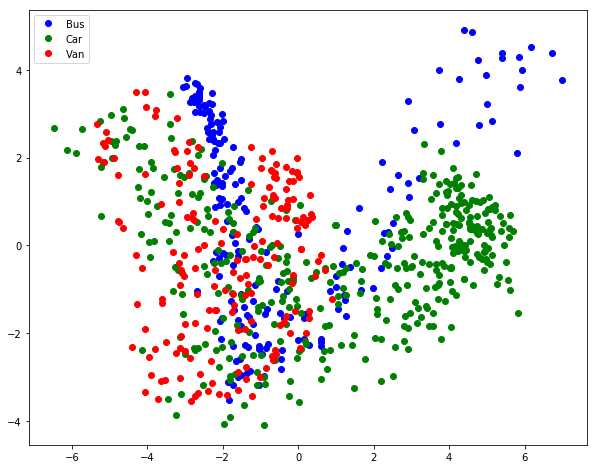

In [20]:
fig = plt.figure(1, figsize=(10, 8))

plt.plot(X_pca[y == 0, 0], X_pca[y == 0, 1], 'bo', label='Bus')
plt.plot(X_pca[y == 1, 0], X_pca[y == 1, 1], 'go', label='Car')
plt.plot(X_pca[y == 2, 0], X_pca[y == 2, 1], 'ro', label='Van')
plt.legend(loc=0)

plt.show()

In [21]:
pd.DataFrame(pca.components_).shape

(17, 17)

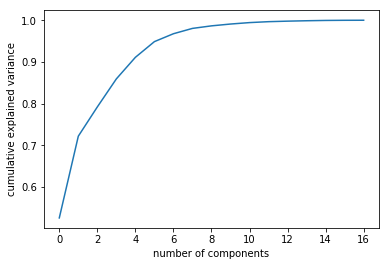

In [22]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

In [23]:
print(pca.explained_variance_ratio_)

[5.25744719e-01 1.96108587e-01 7.01988225e-02 6.72582407e-02
 5.17283266e-02 3.76650637e-02 1.89355265e-02 1.27940479e-02
 6.08796785e-03 4.37890877e-03 3.44732722e-03 2.23114784e-03
 1.25204538e-03 9.63690663e-04 7.28314430e-04 3.62830028e-04
 1.14433677e-04]


In [24]:
print(pca.explained_variance_)

[8.94913348e+00 3.33812563e+00 1.19491192e+00 1.14485786e+00
 8.80510412e-01 6.41128041e-01 3.22317178e-01 2.17778017e-01
 1.03628310e-01 7.45370094e-02 5.86797932e-02 3.79782033e-02
 2.13120947e-02 1.64037717e-02 1.23972392e-02 6.17602845e-03
 1.94786978e-03]


In [25]:
print(pca.singular_values_)

[83.49476018 50.99411596 30.50961138 29.86376185 26.19002884 22.34812619
 15.84566444 13.02494051  8.98479013  7.61999543  6.76103239  5.43921138
  4.07457013  3.57470813  3.1076437   2.19342795  1.23182408]


### From the Elbow plot and the variance carried by each PC's it observed that the components 0 to 9 hold the most of the variance in the dataset.

### So the Dimensions can be reduced to 9

In [26]:
X_centered = X - X.mean(axis=0)

pca = PCA(n_components=9)
pca.fit(X_centered)

X_pca = pca.transform(X_centered)
X_pca.shape

(780, 9)

In [27]:
print(pca.explained_variance_ratio_)

[0.52574472 0.19610859 0.07019882 0.06725824 0.05172833 0.03766506
 0.01893553 0.01279405 0.00608797]


In [28]:
pca.components_

array([[ 0.28586055,  0.30125081,  0.31588068,  0.28643772,  0.10718299,
         0.21243025,  0.32372673,  0.32123176,  0.29037114,  0.31556006,
         0.32133075,  0.27322878, -0.05488753,  0.03907343,  0.06631304,
         0.03775876,  0.0945378 ],
       [-0.08608888,  0.14671202, -0.03965584, -0.19625806, -0.24886729,
        -0.08170213,  0.07250009,  0.08562273,  0.13367899,  0.06850419,
         0.07594698,  0.21348924,  0.50460307, -0.01323568, -0.08682508,
        -0.50758445, -0.50585402],
       [ 0.02425219, -0.19792949,  0.10317651, -0.02511098, -0.28017796,
        -0.04665778,  0.11192985,  0.1194849 , -0.18632526,  0.12485565,
         0.11379759, -0.22167502,  0.02993046, -0.36482303,  0.76846067,
        -0.06624496, -0.01306192],
       [-0.12785559, -0.0235991 , -0.06771374,  0.26410522,  0.55873389,
        -0.32196345,  0.0497984 ,  0.02301779, -0.10676625,  0.11207313,
         0.05565849,  0.02076655,  0.14693839, -0.63424145, -0.16533767,
         0.00722879

In [29]:
components_data = pca.components_
pd.DataFrame(components_data)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0.285861,0.301251,0.315881,0.286438,0.107183,0.212430,0.323727,0.321232,0.290371,0.315560,0.321331,0.273229,-0.054888,0.039073,0.066313,0.037759,0.094538
1,-0.086089,0.146712,-0.039656,-0.196258,-0.248867,-0.081702,0.072500,0.085623,0.133679,0.068504,0.075947,0.213489,0.504603,-0.013236,-0.086825,-0.507584,-0.505854
2,0.024252,-0.197929,0.103177,-0.025111,-0.280178,-0.046658,0.111930,0.119485,-0.186325,0.124856,0.113798,-0.221675,0.029930,-0.364823,0.768461,-0.066245,-0.013062
3,-0.127856,-0.023599,-0.067714,0.264105,0.558734,-0.321963,0.049798,0.023018,-0.106766,0.112073,0.055658,0.020767,0.146938,-0.634241,-0.165338,0.007229,-0.105713
4,0.131559,-0.110417,-0.074612,0.153825,0.167245,-0.597535,0.080240,0.071680,-0.235990,0.146937,0.109336,0.007933,0.165019,0.598972,0.177995,0.149123,-0.124329
5,0.298470,-0.050922,-0.032616,-0.110702,-0.561826,-0.346552,0.108023,0.114856,-0.081454,0.157901,0.147166,-0.067317,-0.107482,-0.261522,-0.462652,0.285547,0.033299
6,0.258594,-0.368740,0.167310,0.163031,0.113685,0.390736,0.097300,0.099549,-0.333659,0.085224,0.078851,-0.471538,0.092540,0.115235,-0.301011,-0.252567,-0.184974
7,-0.714658,-0.078343,0.357312,0.105568,-0.163479,-0.063868,0.117908,0.082757,-0.275075,0.180190,0.084900,0.146468,-0.330297,0.107000,-0.148438,-0.114857,-0.013698
8,-0.441318,-0.020102,-0.229309,-0.117684,0.005004,0.123866,0.215931,0.213647,0.262504,0.094863,0.207310,-0.404128,0.425180,0.086600,-0.063522,0.306554,0.245500


## Question 4. Use Support vector machines and use grid search (try C values - 0.01, 0.05, 0.5, 1 and kernel = linear, rbf) and find out the best hyper parameters and do cross validation to find the accuracy. (10 points)

In [30]:
X_pca_train, X_pca_test, y_train, y_test = train_test_split(X_pca, y, test_size=.3, 
                                                    stratify=y, 
                                                    random_state=42)
param_grid = [    {        
     'kernel': ['linear', 'rbf'],        
     'C': [ 0.01, 0.05, 0.5, 1.0 ]    } ]

#Apply GridSearch with cross-validation to find the best hyper parameters and best accuracy score
# 'CV' value is considered as 10
gs = GridSearchCV(estimator=svm.SVC(), param_grid=param_grid, scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())
X_train_scaled = X_pca_train
gs.fit(X_train_scaled, y_train)

/home/siju/.local/lib/python3.6/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)
/home/siju/.local/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


GridSearchCV(cv=10, error_score='raise-deprecating',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False),
       fit_params=None, iid='warn', n_jobs=12,
       param_grid=[{'kernel': ['linear', 'rbf'], 'C': [0.01, 0.05, 0.5, 1.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring='accuracy', verbose=0)

In [31]:
print("Best Hyperparameter:\n\n", gs.best_estimator_)

Best Hyperparameter:

 SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)


In [32]:
print("Best Accuracy Score :\n\n", gs.best_score_)

Best Accuracy Score :

 0.9578754578754579


In [33]:
start_time = time.time()
prediction = gs.best_estimator_.predict(X_pca_test)
print("Time taken for PCA data prediction:", time.time()-start_time)
# Accuracy
print("Test data Accuracy on PCA data model:",metrics.accuracy_score(prediction,y_test))

Time taken for PCA data prediction: 0.0017905235290527344
Test data Accuracy on PCA data model: 0.9487179487179487


In [34]:
### Use the original data and mesure the accuracy and execution time differance

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, 
                                                    stratify=y, 
                                                    random_state=42)
import multiprocessing 
from sklearn.model_selection import GridSearchCV
from sklearn import svm
param_grid = [    {        
     'kernel': ['linear', 'rbf'],        
     'C': [ 0.01, 0.05, 0.5, 1.0 ]    } ]

#Apply GridSearch with cross-validation to find the best hyper parameters and best accuracy score
# 'CV' value is considered as 10
gs = GridSearchCV(estimator=svm.SVC(), param_grid=param_grid, scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())
X_train_scaled = X_train
gs.fit(X_train_scaled, y_train)
print("Best Accuracy Score:", gs.best_score_)

start_time = time.time()
prediction = gs.best_estimator_.predict(X_test)
print("Time taken for non-PCA data prediction:", time.time()-start_time)
# Accuracy
print("Test data Accuracy on on-PCA model:",metrics.accuracy_score(prediction,y_test))

Best Accuracy Score: 0.9652014652014652
Time taken for non-PCA data prediction: 0.0023293495178222656
Test data Accuracy on on-PCA model: 0.9572649572649573


/home/siju/.local/lib/python3.6/site-packages/sklearn/model_selection/_search.py:841: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)
/home/siju/.local/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


### Model created with a PCA applied data is taken less time on prediction. (model complexity is reduced)
#### Time taken for PCA data prediction: 0.0017905235290527344
#### Time taken for non-PCA data prediction: 0.0023293495178222656